In [1]:
import os
import sys
import time
import h5py
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm
from pathlib import Path

from imu_ssl.datasets.data_index import DataIndex
from imu_ssl.datasets.imu_dataset import build_dataloader, IMUDataset
from imu_ssl.datasets.imu_augmentation import Compose, Jitter, Scaling, RandomCrop, TimeWarp
from imu_ssl.models.tcn_encoder import TCNEncoder
from imu_ssl.models.SimCLR_model import SimCLR
from imu_ssl.inference.simclr_inference import SimCLRInference

In [2]:
# Use absolute path since __file__ is not available in notebooks
PROJECT_ROOT = Path(os.getcwd()).parent if "scripts" in os.getcwd() else Path(os.getcwd()) / "imu_ssl"
DATA_DIR = PROJECT_ROOT / "data"

CHECKPOINT = PROJECT_ROOT / "checkpoints" / "best.pt"
TRAIN_METADATA = DATA_DIR / "metadata_train.json"
VAL_METADATA = DATA_DIR / "metadata_val.json"

EXPAND_FACTOR = 40
BATCH_SIZE = 256
SEQ_LEN = 1000
EPOCHS = 30
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"TRAIN_METADATA: {TRAIN_METADATA}")
print(f"VAL_METADATA: {VAL_METADATA}")

print(f"Using device: {DEVICE}")
print(f"Note: Using original IMU data for training and validation")

PROJECT_ROOT: d:\Desktop\MCI-project\imu_ssl
TRAIN_METADATA: d:\Desktop\MCI-project\imu_ssl\data\metadata_train.json
VAL_METADATA: d:\Desktop\MCI-project\imu_ssl\data\metadata_val.json
Using device: cuda
Note: Using original IMU data for training and validation


In [3]:
def get_augmentation():
    return Compose([
        Jitter(0.02),
        Scaling(0.1),
        # RandomCrop(0.9),
        TimeWarp(0.2),
    ])


In [4]:
def compute_imu_normalizer(file_list):
    """Compute mean and std for IMU data normalization across all files."""
    print("Computing IMU normalizer statistics...")
    all_samples = []
    for path in tqdm(file_list, desc="Loading files for normalization"):
        imu, ts = IMUDataset._load_hdf5(IMUDataset, path)  # unnormalized raw imu
        all_samples.append(imu)

    concat = np.vstack(all_samples)   # (Total_T, 9)
    mean = concat.mean(axis=0)
    std = concat.std(axis=0)
    
    print(f"Normalizer computed:")
    print(f"  Mean: {mean}")
    print(f"  Std:  {std}")

    return {"mean": mean, "std": std}

In [5]:
# ===== Normalizer Save/Load Block (Run once) =====
import json

# Load training files
train_index = DataIndex(TRAIN_METADATA)
train_files = train_index.all_file_list()

# Use IMU normalizer instead of feature engineering normalizer
normalizer_json_path = PROJECT_ROOT / "checkpoints" / "imu_normalizer.json"

# Check if IMU normalizer exists, if not compute it
if not normalizer_json_path.exists():
    print("Computing IMU normalizer...")
    normalizer = compute_imu_normalizer(train_files)
    with open(normalizer_json_path, "w") as f:
        json.dump({k: v.tolist() for k, v in normalizer.items()}, f)
    print(f"IMU normalizer saved to: {normalizer_json_path}")
else:
    # Load normalizer (for verification)
    with open(normalizer_json_path) as f:
        loaded_normalizer = json.load(f)
        loaded_normalizer["mean"] = np.array(loaded_normalizer["mean"])
        loaded_normalizer["std"] = np.array(loaded_normalizer["std"])
    print("IMU normalizer loaded successfully!")
    print(f"Mean: {loaded_normalizer['mean']}")
    print(f"Std:  {loaded_normalizer['std']}")

IMU normalizer loaded successfully!
Mean: [ 1.64419577e-01 -3.88058687e-02  6.20334869e-01  4.69063510e-01
  1.28494974e+00  5.75370123e-01 -5.44671420e+01  4.46846774e+01
 -5.64108098e+01]
Std:  [ 0.7029288   0.46806652  0.4245466  27.20818685 50.01501971 42.74143293
 30.7526438  39.25963613 51.80502971]


In [6]:
def train_simclr():
    train_loss_history = []
    
    print("Loading training metadata:", TRAIN_METADATA)
    train_index = DataIndex(TRAIN_METADATA)
    train_files = train_index.all_file_list()
    print("Train samples:", len(train_files))

    normalizer_json_path = PROJECT_ROOT / "checkpoints" / "imu_normalizer.json"
    with open(normalizer_json_path) as f:
        normalizer = json.load(f)
        normalizer["mean"] = np.array(normalizer["mean"])
        normalizer["std"] = np.array(normalizer["std"])
    
    augment = get_augmentation()
    train_loader = build_dataloader(
        file_list=train_files,
        batch_size=BATCH_SIZE,
        shuffle=True,
        augment=augment,
        expand_factor=EXPAND_FACTOR,
        target_seq_len=SEQ_LEN,
        imu_normalizer=normalizer
    )
    
    input_dim = 9  # Original IMU has 9 channels (3 acc + 3 gyro + 3 mag)
    print(f"Using original IMU data")
    print(f"Input dimension: {input_dim}")

    encoder = TCNEncoder(input_ch=input_dim)  # Use original IMU dimensions
    model = SimCLR(encoder).to(DEVICE)
    
    # Print model structure and parameters
    print("\n" + "="*60)
    print("MODEL STRUCTURE")
    print("="*60)
    print(model)
    print("\n" + "="*60)
    
    # Count trainable parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model created with {total_params:,} trainable parameters")
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_train_loss = float("inf")

    for epoch in range(1, EPOCHS + 1):
        print(f"Epoch {epoch}/{EPOCHS}")
        
        # ===== Training =====
        model.train()
        train_loss_sum = 0.0

        for x1, x2 in tqdm(train_loader, desc="Training"):
            x1 = x1.to(DEVICE)
            x2 = x2.to(DEVICE)

            loss = model(x1, x2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()

        avg_train_loss = train_loss_sum / len(train_loader)
        train_loss_history.append(avg_train_loss)
        
        scheduler.step()
        
        print(f"Train Loss: {avg_train_loss:.4f}")

        # Save checkpoints
        torch.save(model.state_dict(), PROJECT_ROOT / "checkpoints" / "latest.pt")
        if avg_train_loss < best_train_loss:  # Use training loss for best model selection
            best_train_loss = avg_train_loss
            torch.save(model.state_dict(), PROJECT_ROOT / "checkpoints" / "best.pt")
            print(f"✓ updated best model (train_loss={best_train_loss:.4f})")

    print("Training finished.")
    return train_loss_history, normalizer

In [7]:
train_loss_history, normalizer = train_simclr()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Plot training loss only
plt.plot(train_loss_history, marker='o', label='Train Loss', color='blue')
plt.title("SimCLR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {train_loss_history[-1]:.4f}")
print(f"Best Training Loss: {min(train_loss_history):.4f} (Epoch {train_loss_history.index(min(train_loss_history)) + 1})")

# Print normalizer stats
print(f"\nNormalizer Statistics:")
print(f"Mean shape: {normalizer['mean'].shape}")
print(f"Std shape: {normalizer['std'].shape}")

# Save training history
import pickle
results_path = PROJECT_ROOT / "checkpoints" / "training_results.pkl"
with open(results_path, 'wb') as f:
    pickle.dump({
        'train_loss_history': train_loss_history,
        'normalizer': normalizer
    }, f)
print(f"Training results saved to: {results_path}")

Training:   0%|          | 0/50 [00:16<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def extract_embeddings(model, file_list, normalizer):
    embeddings, labels = [], []
    for path in tqdm(file_list):
        # Load original IMU data and normalize it
        imu, _ = IMUDataset._load_hdf5(IMUDataset, path)
        # Apply normalization
        imu = (imu - normalizer["mean"]) / normalizer["std"]
        emb = model.encode(imu)
        embeddings.append(emb)
        labels.append(os.path.basename(os.path.dirname(path)))
    return np.vstack(embeddings), np.array(labels)

def recall_at_k(embeddings, labels, k=5):
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    N = len(embeds)
    recalls = []

    for i in range(N):
        query_label = labels[i]

        same_class_idx = np.where(labels == query_label)[0]
        total_relevant = len(same_class_idx) - 1

        if total_relevant <= 0:
            continue

        sims = embeds @ embeds[i]
        sims[i] = -1
        topk_idx = np.argsort(-sims)[:k]

        retrieved_relevant = np.sum(labels[topk_idx] == query_label)

        recall = retrieved_relevant / total_relevant
        recalls.append(recall)

    return np.mean(recalls)

def precision_at_k(embeddings, labels, k=5):
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    N = len(embeds)
    precisions = []

    for i in range(N):
        query_label = labels[i]

        sims = embeds @ embeds[i]
        sims[i] = -1
        topk_idx = np.argsort(-sims)[:k]

        retrieved_relevant = np.sum(labels[topk_idx] == query_label)

        precision = retrieved_relevant / k
        precisions.append(precision)

    return np.mean(precisions)


def compute_map(embeddings, labels):
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    N = len(embeds)
    APs = []

    for i in range(N):
        query_label = labels[i]

        # Compute similarity
        sims = embeds @ embeds[i]
        sims[i] = -1
        ranked = np.argsort(-sims)
        ranked_labels = labels[ranked]

        # Find relevant indices
        relevant_mask = ranked_labels == query_label
        rel_pos = np.where(relevant_mask)[0]  # ranked positions of relevant items

        # If no relevant items exist other than itself → skip
        if len(rel_pos) == 0:
            APs.append(0.0)
            continue

        # Compute precision at each relevant retrieval
        precisions = []
        for idx, pos in enumerate(rel_pos):
            precision_at_pos = (idx + 1) / (pos + 1)
            precisions.append(precision_at_pos)

        APs.append(np.mean(precisions))

    return np.mean(APs)

In [ ]:
val_index = DataIndex(VAL_METADATA)
val_files = val_index.all_file_list()
model = SimCLRInference(input_ch=9, checkpoint_path=CHECKPOINT, device=DEVICE)

# Load normalizer for evaluation
normalizer_json_path = PROJECT_ROOT / "checkpoints" / "imu_normalizer.json"
with open(normalizer_json_path) as f:
    eval_normalizer = json.load(f)
    eval_normalizer["mean"] = np.array(eval_normalizer["mean"])
    eval_normalizer["std"] = np.array(eval_normalizer["std"])

embeddings, labels = extract_embeddings(model, val_files, eval_normalizer)

r1 = recall_at_k(embeddings, labels, k=1)
r5 = recall_at_k(embeddings, labels, k=5)
r10 = recall_at_k(embeddings, labels, k=10)
p1 = precision_at_k(embeddings, labels, k=1)
p5 = precision_at_k(embeddings, labels, k=5)
p10 = precision_at_k(embeddings, labels, k=10)
mAP = compute_map(embeddings, labels)

print("Evaluation on Validation Set:")
print("Recall@1 =", r1)
print("Recall@5 =", r5)
print("Recall@10 =", r10)
print("Precision@1 =", p1)
print("Precision@5 =", p5)
print("Precision@10 =", p10)
print("mAP =", mAP)

100%|██████████| 178/178 [00:00<00:00, 399.85it/s]

Evaluation on Validation Set:
Recall@1 = 0.08988764044943819
Recall@5 = 0.26990369181380414
Recall@10 = 0.35366506153023003
Precision@1 = 0.6067415730337079
Precision@5 = 0.3629213483146067
Precision@10 = 0.23820224719101124
mAP = 0.29805559346554644


Creating t-SNE visualization...
Reducing 256D embeddings to 2D using TSNE...


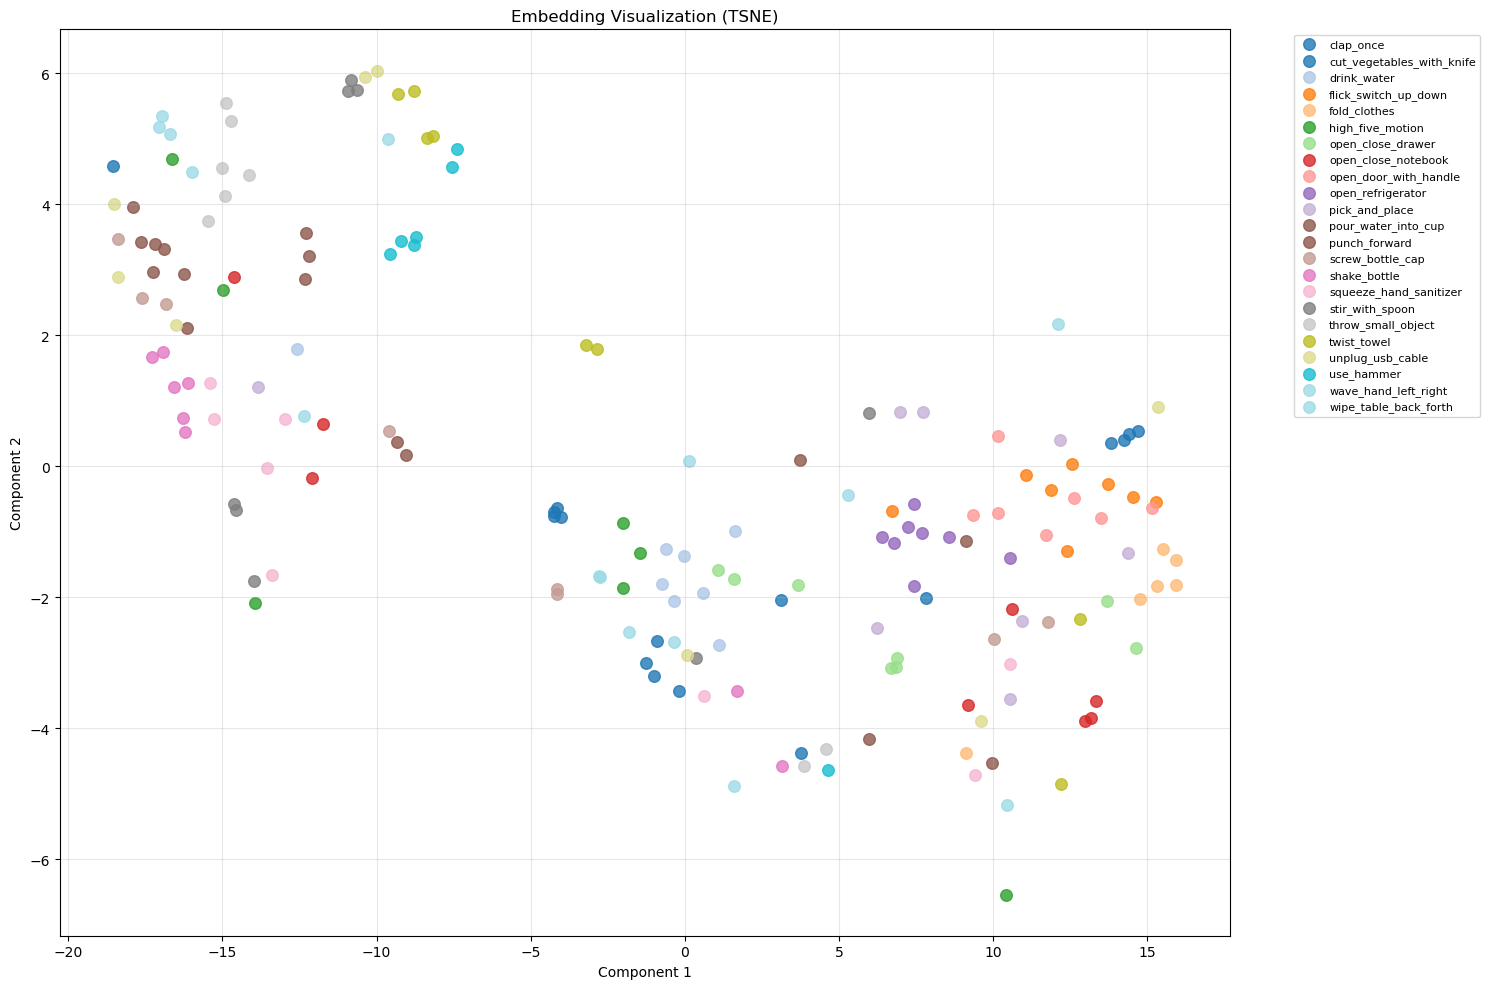

In [ ]:
# Visualize embeddings in 2D space
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def visualize_embeddings_2d(embeddings, labels, method='tsne', figsize=(12, 8)):
    """
    Visualize embeddings in 2D space using dimensionality reduction.
    
    Args:
        embeddings: (N, D) array of embeddings
        labels: (N,) array of class labels
        method: 'tsne' or 'umap' for dimensionality reduction
        figsize: figure size for the plot
    """
    
    print(f"Reducing {embeddings.shape[1]}D embeddings to 2D using {method.upper()}...")
    
    if method == 'tsne':
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        embeddings_2d = reducer.fit_transform(embeddings)
    elif method == 'umap':
        import umap
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
        embeddings_2d = reducer.fit_transform(embeddings)
    else:
        raise ValueError("Method must be 'tsne' or 'umap'")
    
    # Create color map for different classes
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    plt.figure(figsize=figsize)
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                   c=[colors[i]], label=label, alpha=0.8, s=70)
    
    plt.title(f'Embedding Visualization ({method.upper()})')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return embeddings_2d

# Visualize with t-SNE
print("Creating t-SNE visualization...")
embeddings_2d_tsne = visualize_embeddings_2d(embeddings, labels, method='tsne', figsize=(15, 10))

# Also try UMAP if available
# print("\nCreating UMAP visualization...")
# embeddings_2d_umap = visualize_embeddings_2d(embeddings, labels, method='umap', figsize=(15, 10))